In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, classification_report,
    roc_curve
)

if os.path.exists("data"):
    DATA_DIR = "data"
elif os.path.exists("../data"):
    DATA_DIR = "../data"

plt.style.use('seaborn-v0_8-darkgrid')
print(f"✅ Папка данных: {DATA_DIR}")

✅ Папка данных: ../data


In [2]:
df = pd.read_csv(f"{DATA_DIR}/synthetic_data.csv")
print(f"📊 Датасет: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"\n📋 Колонки: {list(df.columns)}")
print(f"\n📈 Распределение default:")
print(df['default'].value_counts())
print(f"\nДоля дефолтов: {df['default'].mean():.1%}")
df.head()

📊 Датасет: 1000 строк, 9 колонок

📋 Колонки: ['income', 'expense', 'balance', 'active_cards', 'days_on_platform', 'closed_credits', 'has_overdue', 'debt_ratio', 'default']

📈 Распределение default:
default
0    767
1    233
Name: count, dtype: int64

Доля дефолтов: 23.3%


,income,expense,balance,active_cards,days_on_platform,closed_credits,has_overdue,debt_ratio,default
0,25973.713224,13597.421746,146241.086251,3,234,0,0,0.523507,1
1,20893.885591,11698.534732,172774.066464,5,313,1,0,0.559902,0
2,27181.508305,8238.521480,140379.003950,1,324,1,0,0.303093,0
3,34184.238851,5412.252889,164601.923518,5,328,1,0,0.158326,0
4,20126.773002,10792.893254,85319.266652,2,251,0,1,0.536246,1


In [3]:
feature_cols = ['income', 'expense', 'debt_ratio', 'balance', 
                'active_cards', 'days_on_platform', 'closed_credits', 'has_overdue']

X = df[feature_cols]
y = df['default']

print(f"✅ Признаки: {X.shape}")
print(f"✅ Target: {y.shape}")

✅ Признаки: (1000, 8)
✅ Target: (1000,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"🎓 Train: {X_train.shape[0]} объектов")
print(f"🧪 Test: {X_test.shape[0]} объектов")

🎓 Train: 800 объектов
🧪 Test: 200 объектов


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Признаки масштабированы")

✅ Признаки масштабированы


In [6]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
    }

print("✅ Модели обучены")

✅ Модели обучены


In [7]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1'],
        'ROC-AUC': r['roc_auc'],
    }
    for name, r in results.items()
}).T

comparison = comparison.round(3).sort_values('ROC-AUC', ascending=False)
print("🏆 Сравнение моделей:")
comparison

🏆 Сравнение моделей:


,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.77,0.524,0.234,0.324,0.727
Logistic Regression,0.77,0.529,0.191,0.281,0.675
Decision Tree,0.73,0.333,0.149,0.206,0.667


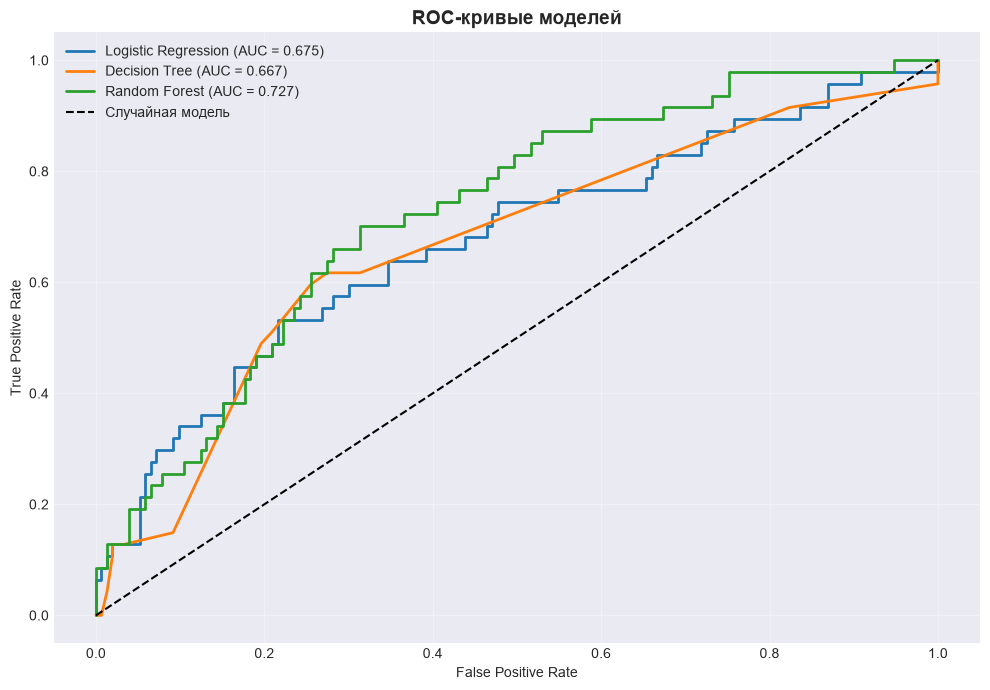

In [8]:
plt.figure(figsize=(10, 7))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {r['roc_auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

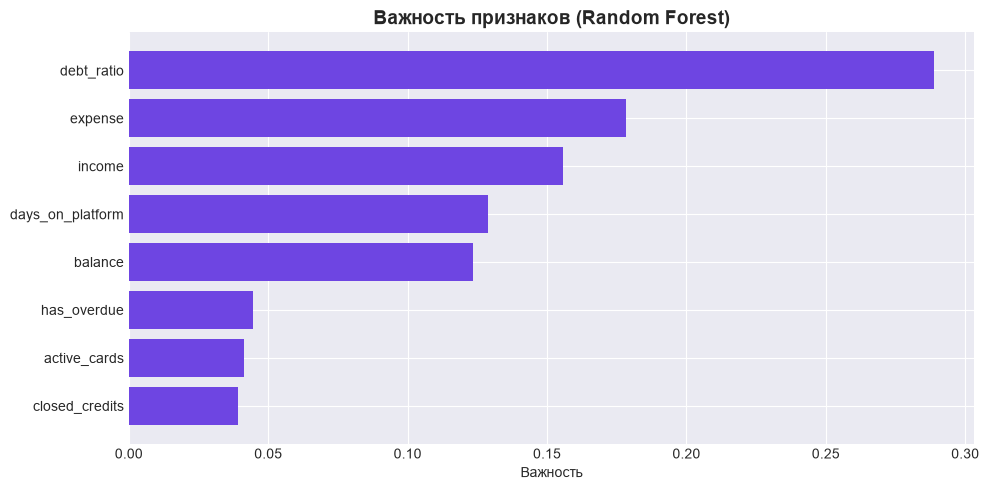

🏆 Топ признаков:


,feature,importance
2,debt_ratio,0.288800
1,expense,0.178361
0,income,0.155760
5,days_on_platform,0.128894
3,balance,0.123400
7,has_overdue,0.044530
4,active_cards,0.041152
6,closed_credits,0.039103


In [9]:
rf_model = results['Random Forest']['model']
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importances['feature'], importances['importance'], color='#6e45e2')
plt.xlabel('Важность')
plt.title('Важность признаков (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("🏆 Топ признаков:")
importances